In [1]:
import mne
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import os
from Parameters import path_directory, subject_to_pop
from Import_data import import_df_description, Make_path_list
from Tools import  find_participant
import seaborn as sns
import pandas as pd

In [2]:
fs_dir = mne.datasets.fetch_fsaverage(verbose=True)
mne.datasets.fetch_aparc_sub_parcellation(subjects_dir=fs_dir)

subjects_dir = Path(fs_dir).parent
subject='fsaverage'

model = mne.make_bem_model(subject = subject, subjects_dir = subjects_dir)
bem = mne.make_bem_solution(model)

labels = mne.read_labels_from_annot(
    subject=subject,
    parc='aparc',
    subjects_dir=subjects_dir
)

0 files missing from root.txt in C:\Users\hugop\mne_data\MNE-fsaverage-data
0 files missing from bem.txt in C:\Users\hugop\mne_data\MNE-fsaverage-data\fsaverage
Creating the BEM geometry...
Going from 5th to 4th subdivision of an icosahedron (n_tri: 20480 -> 5120)
Going from 5th to 4th subdivision of an icosahedron (n_tri: 20480 -> 5120)
Going from 5th to 4th subdivision of an icosahedron (n_tri: 20480 -> 5120)
outer skin  CM is  -0.21 -19.38  -0.23 mm
outer skull CM is  -0.19 -19.34  -0.49 mm
inner skull CM is  -0.53 -21.10   6.21 mm
Checking that surface outer skull is inside surface outer skin  ...
Checking that surface inner skull is inside surface outer skull ...
Checking distance between outer skin  and outer skull surfaces...
Minimum distance between the outer skin  and outer skull surfaces is approximately    1.6 mm
Checking distance between outer skull and inner skull surfaces...
Minimum distance between the outer skull and inner skull surfaces is approximately    5.4 mm
Surfa

In [3]:
class Parcellation():
    def __init__(self,subjects_dir,subject):

        self.labels = mne.read_labels_from_annot(subject=subject,parc='aparc',subjects_dir=subjects_dir)
        self.dict_function = make_dict_function(self.labels)
        self.dict_vertices = make_dict_vertices(self.dict_function)
        self.src = mne.setup_source_space(subject=subject,spacing='ico5',subjects_dir=subjects_dir,add_dist=False)
        self.R = make_R_matrix(self.dict_vertices,self.src)
class Forward():
    def __init__(self,subjects_dir,subject):
        
        self.bem = make_bem(subject,subjects_dir)
        self.src = mne.setup_source_space(subject=subject,spacing='ico5',subjects_dir=subjects_dir,add_dist=False)
        self.info = make_info()
        self.forward = make_fwd(self.info,self.src,self.bem)
        self.G = self.forward["sol"]["data"]
        self.G_mean_reference = self.G - np.mean(self.G, axis=0, keepdims=True)

class True_EEG():
    def __init__(self,average_individual, average_group, name):
        self.average_individual = average_individual 
        self.average_group = average_group
        self.name = name

class Simulation():
    def __init__(self,Parcellation,Forward,True_EEG,Lambda):
        self.G = Forward.G
        self.R = Parcellation.R
        self.true_eeg_group = True_EEG.average_group.data
        self.true_eeg_sub = True_EEG.average_individual.data
        self.name = True_EEG.name
        
        self.GR = make_GR_Region(self.G,self.R)
        self.Alpha_matrix = make_alpha_matrix(self.GR,self.true_eeg_group,Lambda)
        
        self.sim_eeg = self.GR @ self.Alpha_matrix
        self.info = True_EEG.average_group.info
        self.raw_sim_eeg = mne.io.RawArray(self.sim_eeg,self.info)
        self.evoked_sim = mne.EvokedArray(self.sim_eeg, self.info, tmin=-0.2)

class Simulation_seriel():
    def __init__(self,Parcellation,Forward,True_EEG,Lambda,constraint = [0,200,275,350,600,900]):
        self.G = Forward.G
        self.R = Parcellation.R
        self.true_eeg_group = True_EEG.average_group.data
        self.true_eeg_sub = True_EEG.average_individual.data
        self.info = True_EEG.average_group.info
        
        self.GR = make_GR_Region(self.G,self.R)
        self.Alpha_matrix = make_alpha_matrix_seriel(self.GR,self.true_eeg_group,Lambda,constraint,sfreq=self.info["sfreq"])
        self.sim_eeg = self.GR @ self.Alpha_matrix
        
        self.raw_sim_eeg = mne.io.RawArray(self.sim_eeg,self.info)   
        self.evoked_sim = mne.EvokedArray(self.sim_eeg, self.info, tmin=-0.2)

####################### Fonctions pour Simulation_seriel ######################

def make_alpha_matrix_seriel(GR,eeg_group,lamb,constraint,sfreq, gap = 0.2):

    def make_constraint(constraint,time,gap = gap, sfreq = sfreq):
        liste_out = []
        sf_gap = int(gap * sfreq)
        for i in range(len(constraint)):
            if i == len(constraint) -1:
                liste_out.append((int(constraint[i] * sfreq / 1000) + sf_gap,time))
            else :
                liste_out.append((int(constraint[i] * sfreq / 1000)+ sf_gap,int(constraint[i+1]* sfreq / 1000)+ sf_gap))
        return liste_out
    
    region = GR.shape[1]
    time = eeg_group.shape[1]
    alpha = np.zeros((region,time))
    time_constraint = make_constraint(constraint,time)

    for i, t_c in enumerate(time_constraint):
        GR_sub = GR[:,[i]]
        base = GR_sub.T @ GR_sub + lamb * np.eye(GR_sub.shape[1])

        for t in range(t_c[0], t_c[1]):
            eeg_t = eeg_group[:,t]
            alpha[i, t] = np.linalg.solve(base, GR_sub.T @ eeg_t)[0]
        
    return alpha

####################### Fonctions pour Simulation ######################

def make_GR_Region(G,R):
    """ 
    transform of G matrix (n_channels, n_vertices) and R matrix (n_vertices, n_area) in GR matrix (n_channels, n_area) where n_region is a group of vertice
    """
    return G @ R

def make_alpha_matrix(GR,eeg_group,lamb):
    """ 
    la matrice alpha c'est la matrice qui contient toutes les sources les plus representative du signal eeg moyen
    """
    region = GR.shape[1]
    time = eeg_group.shape[1]
    alpha = np.zeros((region,time))
    base = GR.T @ GR + lamb * np.eye(GR.shape[1])

    for t, eeg_t in enumerate(eeg_group.T):
        alpha[:, t] = np.linalg.solve(base,GR.T @ eeg_t)
    return alpha

####################### Fontions pour Forward ##########################

def make_bem(subject,subjects_dir) :
    model = mne.make_bem_model(subject = subject, subjects_dir = subjects_dir)
    return mne.make_bem_solution(model)

def make_info():
    montage = mne.channels.make_standard_montage("biosemi128")
    info = mne.create_info(
        ch_names= montage.ch_names,
        sfreq=512,
        ch_types="eeg"
    )
    info.set_montage(montage)
    return info

def make_fwd(info,src,bem):
    forward = mne.make_forward_solution(info,trans="fsaverage",src=src,bem=bem,eeg=True)
    forward_fixed = mne.convert_forward_solution(forward,surf_ori=True,force_fixed=True)
    return forward_fixed

######################## Fonctions pour Parcellation ########################


def make_dict_function(labels):

    temp_regions = []
    temp_regions_supp = []
    occ_regions = []
    broca_region = []
    region_motrice = []
    region_bruit = []


    for l in labels:
        if 'occ' in l.name or 'fusi' in l.name or 'pericalca' in l.name or 'cuneus-rh' == l.name or 'cuneus-lh' == l.name:
            occ_regions.append(l)

    for l in labels:
        if 'temp' in l.name:
            temp_regions.append(l)

    for l in labels:
        if 'marginal' in l.name:
            temp_regions_supp.append(l)
    
    for l in labels :
        if 'opercularis' in l.name or 'precentral' in l.name or 'triangularis' in l.name : #or 'pars' in l.name:
            broca_region.append(l)

    for l in labels :
        if 'postcentral' in l.name or 'insula' in l.name or 'precentral' in l.name:
            region_motrice.append(l)

    for l in labels :
        if 'frontal' in l.name or 'Pars' in l.name:
            region_bruit.append(l)

    Visuel_conceptuel = occ_regions
    lexico_seman = temp_regions[:4]
    lexico_phono = temp_regions[4:]
    lexico_phono2 = temp_regions_supp                     
    lexico_phono.extend(lexico_phono2)
    phono = broca_region
    articulation = region_motrice
    bruit = region_bruit[:4]
    bruit2 = region_bruit[6:]
    bruit.extend(bruit2)

    dico_fonction = {
        'visuo_conceptuel' : Visuel_conceptuel,
        'lexico_semantique' : lexico_seman,
        'lexico_phonologique' : lexico_phono,
        'phonologique' : phono,
        'articulation' : articulation,
        'bruit' : bruit,
    }

    return dico_fonction

def make_dict_vertices(dict_function):
    dico_vertices = {}
    for key, value in dict_function.items():
        dico_vertices[key] = {
            "lh" : [],
            "rh" : [],
        }
        for sous_region in value :
            if sous_region.hemi == 'lh' :
                dico_vertices[key]["lh"].append(sous_region.vertices)
            elif sous_region.hemi == 'rh' :
                dico_vertices[key]["rh"].append(sous_region.vertices)

        dico_vertices[key]["lh"] = np.concatenate(dico_vertices[key]["lh"])
        dico_vertices[key]["rh"] = np.concatenate(dico_vertices[key]["rh"])
    
    return dico_vertices

def make_R_matrix(dict_vertices,src):
    """ 
    permet de creer la matrice qui stoque l'information, quel vertice fait parti de quel region
    """

    n_vertices_lh = src[0]['nuse'] 
    n_vertices_rh = src[1]['nuse']
    n_regions = len(dict_vertices)

    R_matrix = np.zeros((n_vertices_lh + n_vertices_rh, n_regions))

    for i, verts in enumerate(dict_vertices.values()):

        # gauche
        common, idx_src, idx_labels = np.intersect1d(src[0]['vertno'],verts['lh'],return_indices=True)

        R_matrix[idx_src, i] = 1.0 / len(idx_src)

        # droite
        common, idx_src, idx_labels = np.intersect1d(src[0]['vertno'],verts['lh'],return_indices=True)
        R_matrix[n_vertices_lh + idx_src, i] = 1.0 / len(idx_src)

    """ 
    src[0]['vertno'] =>                             tous les indices des vertices utilises dans mon source space (depend de la resolution, ico6, ico5...)
    verts['lh'] =>                                  tous les vertices compris dans chaque region defini par la parcellation personnalisee
    quand on fait 'np.intersect1d(src,vertno)' =>   on recupere les indices de vertices compris a la fois dans la region d'interet et dans la resolution choisie
    common =>                                       sont les valeurs (indice des vertices sur l'atlas) (pas necessaire)
    idx_src =>                                      sont les position des valeurs dans vertno
    idx_labels =>                                   sont les position des valeurs dans labels (pas necessaire)
    1.0 / len(idx_src) =>                           pas seulement '1' sinon les regions plus grandes montrerons une activite plus forte artificiellement
    """

    return R_matrix

In [4]:
forward_obj = Forward(subjects_dir,subject)

Creating the BEM geometry...
Going from 5th to 4th subdivision of an icosahedron (n_tri: 20480 -> 5120)
Going from 5th to 4th subdivision of an icosahedron (n_tri: 20480 -> 5120)
Going from 5th to 4th subdivision of an icosahedron (n_tri: 20480 -> 5120)
outer skin  CM is  -0.21 -19.38  -0.23 mm
outer skull CM is  -0.19 -19.34  -0.49 mm
inner skull CM is  -0.53 -21.10   6.21 mm
Checking that surface outer skull is inside surface outer skin  ...
Checking that surface inner skull is inside surface outer skull ...
Checking distance between outer skin  and outer skull surfaces...
Minimum distance between the outer skin  and outer skull surfaces is approximately    1.6 mm
Checking distance between outer skull and inner skull surfaces...
Minimum distance between the outer skull and inner skull surfaces is approximately    5.4 mm
Surfaces passed the basic topology checks.
Complete.

Three-layer model surfaces loaded.
Computing the linear collocation solution...
    Matrix coefficients...
     

In [5]:
parcellation_obj = Parcellation(subjects_dir,subject)

Reading labels from parcellation...
   read 35 labels from C:\Users\hugop\mne_data\MNE-fsaverage-data\fsaverage\label\lh.aparc.annot
   read 34 labels from C:\Users\hugop\mne_data\MNE-fsaverage-data\fsaverage\label\rh.aparc.annot
Setting up the source space with the following parameters:

SUBJECTS_DIR = C:\Users\hugop\mne_data\MNE-fsaverage-data
Subject      = fsaverage
Surface      = white
Icosahedron subdivision grade 5

>>> 1. Creating the source space...

Doing the icosahedral vertex picking...
Loading C:\Users\hugop\mne_data\MNE-fsaverage-data\fsaverage\surf\lh.white...
Mapping lh fsaverage -> ico (5) ...
    Triangle neighbors and vertex normals...
Loading geometry from C:\Users\hugop\mne_data\MNE-fsaverage-data\fsaverage\surf\lh.sphere...
Setting up the triangulation for the decimated surface...
loaded lh.white 10242/163842 selected to source space (ico = 5)

Loading C:\Users\hugop\mne_data\MNE-fsaverage-data\fsaverage\surf\rh.white...
Mapping rh fsaverage -> ico (5) ...
    Tri

In [6]:
os.chdir(r"c:\Users\hugop\Desktop\Code_Iconic\Scripts")

In [7]:
path_data, path_stim, path_answers = Make_path_list(path_directory,subject_to_pop)

list_subject = []
for sub_path in path_data:
    list_subject.append(find_participant(sub_path,signe = 'S'))

In [8]:
list_true_eeg = []
for sub in list_subject:

    group_average = mne.read_evokeds(f"../group_average_{sub}.fif")[0]
    subject_average = mne.read_evokeds(f"../subject_average_{sub}.fif")[0]
    list_true_eeg.append(True_EEG(subject_average,group_average,name = sub))

Reading c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\group_average_S01.fif ...
    Found the data of interest:
        t =    -199.22 ...     953.12 ms (Grand average (n = 26))
        0 CTF compensation matrices available
        nave = 26 - aspect type = 100
No projector specified for this dataset. Please consider the method self.add_proj.
Loaded Evoked data is baseline-corrected (baseline: [-0.199219, 0] s)
Reading c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\subject_average_S01.fif ...
    Found the data of interest:
        t =    -199.22 ...     953.12 ms (0.24 × A + 0.52 × B + 0.24 × C)
        0 CTF compensation matrices available
        nave = 123 - aspect type = 100
No projector specified for this dataset. Please consider the method self.add_proj.
Loaded Evoked data is baseline-corrected (baseline: [-0.199219, 0] s)
Reading c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\group_average_S02.fif ...
    Found the data of interest:
        t =    -199.22 ...     953.12 ms (Grand

C:\Users\hugop\AppData\Local\Temp\ipykernel_17660\2604325914.py:4: RuntimeWarning: This filename (c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\group_average_S01.fif) does not conform to MNE naming conventions. All evoked files should end with -ave.fif, -ave.fif.gz, _ave.fif or _ave.fif.gz
  group_average = mne.read_evokeds(f"../group_average_{sub}.fif")[0]
C:\Users\hugop\AppData\Local\Temp\ipykernel_17660\2604325914.py:5: RuntimeWarning: This filename (c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\subject_average_S01.fif) does not conform to MNE naming conventions. All evoked files should end with -ave.fif, -ave.fif.gz, _ave.fif or _ave.fif.gz
  subject_average = mne.read_evokeds(f"../subject_average_{sub}.fif")[0]
C:\Users\hugop\AppData\Local\Temp\ipykernel_17660\2604325914.py:4: RuntimeWarning: This filename (c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\group_average_S02.fif) does not conform to MNE naming conventions. All evoked files should end with -ave.fif, -ave.fif.gz, _ave.fi

    Found the data of interest:
        t =    -199.22 ...     953.12 ms (0.24 × A + 0.48 × B + 0.28 × C)
        0 CTF compensation matrices available
        nave = 147 - aspect type = 100
No projector specified for this dataset. Please consider the method self.add_proj.
Loaded Evoked data is baseline-corrected (baseline: [-0.199219, 0] s)
Reading c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\group_average_S08.fif ...
    Found the data of interest:
        t =    -199.22 ...     953.12 ms (Grand average (n = 26))
        0 CTF compensation matrices available
        nave = 26 - aspect type = 100
No projector specified for this dataset. Please consider the method self.add_proj.
Loaded Evoked data is baseline-corrected (baseline: [-0.199219, 0] s)
Reading c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\subject_average_S08.fif ...
    Found the data of interest:
        t =    -199.22 ...     953.12 ms (0.23 × A + 0.49 × B + 0.28 × C)
        0 CTF compensation matrices available
       

C:\Users\hugop\AppData\Local\Temp\ipykernel_17660\2604325914.py:4: RuntimeWarning: This filename (c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\group_average_S08.fif) does not conform to MNE naming conventions. All evoked files should end with -ave.fif, -ave.fif.gz, _ave.fif or _ave.fif.gz
  group_average = mne.read_evokeds(f"../group_average_{sub}.fif")[0]
C:\Users\hugop\AppData\Local\Temp\ipykernel_17660\2604325914.py:5: RuntimeWarning: This filename (c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\subject_average_S08.fif) does not conform to MNE naming conventions. All evoked files should end with -ave.fif, -ave.fif.gz, _ave.fif or _ave.fif.gz
  subject_average = mne.read_evokeds(f"../subject_average_{sub}.fif")[0]
C:\Users\hugop\AppData\Local\Temp\ipykernel_17660\2604325914.py:4: RuntimeWarning: This filename (c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\group_average_S09.fif) does not conform to MNE naming conventions. All evoked files should end with -ave.fif, -ave.fif.gz, _ave.fi

        t =    -199.22 ...     953.12 ms (0.24 × A + 0.49 × B + 0.27 × C)
        0 CTF compensation matrices available
        nave = 142 - aspect type = 100
No projector specified for this dataset. Please consider the method self.add_proj.
Loaded Evoked data is baseline-corrected (baseline: [-0.199219, 0] s)
Reading c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\group_average_S19.fif ...
    Found the data of interest:
        t =    -199.22 ...     953.12 ms (Grand average (n = 26))
        0 CTF compensation matrices available
        nave = 26 - aspect type = 100
No projector specified for this dataset. Please consider the method self.add_proj.
Loaded Evoked data is baseline-corrected (baseline: [-0.199219, 0] s)
Reading c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\subject_average_S19.fif ...
    Found the data of interest:
        t =    -199.22 ...     953.12 ms (0.23 × A + 0.50 × B + 0.27 × C)
        0 CTF compensation matrices available
        nave = 149 - aspect type = 100


C:\Users\hugop\AppData\Local\Temp\ipykernel_17660\2604325914.py:4: RuntimeWarning: This filename (c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\group_average_S19.fif) does not conform to MNE naming conventions. All evoked files should end with -ave.fif, -ave.fif.gz, _ave.fif or _ave.fif.gz
  group_average = mne.read_evokeds(f"../group_average_{sub}.fif")[0]
C:\Users\hugop\AppData\Local\Temp\ipykernel_17660\2604325914.py:5: RuntimeWarning: This filename (c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\subject_average_S19.fif) does not conform to MNE naming conventions. All evoked files should end with -ave.fif, -ave.fif.gz, _ave.fif or _ave.fif.gz
  subject_average = mne.read_evokeds(f"../subject_average_{sub}.fif")[0]
C:\Users\hugop\AppData\Local\Temp\ipykernel_17660\2604325914.py:4: RuntimeWarning: This filename (c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\group_average_S20.fif) does not conform to MNE naming conventions. All evoked files should end with -ave.fif, -ave.fif.gz, _ave.fi

No projector specified for this dataset. Please consider the method self.add_proj.
Loaded Evoked data is baseline-corrected (baseline: [-0.199219, 0] s)
Reading c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\subject_average_S27.fif ...
    Found the data of interest:
        t =    -199.22 ...     953.12 ms (0.23 × A + 0.51 × B + 0.25 × C)
        0 CTF compensation matrices available
        nave = 138 - aspect type = 100
No projector specified for this dataset. Please consider the method self.add_proj.
Loaded Evoked data is baseline-corrected (baseline: [-0.199219, 0] s)
Reading c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\group_average_S29.fif ...
    Found the data of interest:
        t =    -199.22 ...     953.12 ms (Grand average (n = 26))
        0 CTF compensation matrices available
        nave = 26 - aspect type = 100
No projector specified for this dataset. Please consider the method self.add_proj.
Loaded Evoked data is baseline-corrected (baseline: [-0.199219, 0] s)
Readin

C:\Users\hugop\AppData\Local\Temp\ipykernel_17660\2604325914.py:5: RuntimeWarning: This filename (c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\subject_average_S27.fif) does not conform to MNE naming conventions. All evoked files should end with -ave.fif, -ave.fif.gz, _ave.fif or _ave.fif.gz
  subject_average = mne.read_evokeds(f"../subject_average_{sub}.fif")[0]
C:\Users\hugop\AppData\Local\Temp\ipykernel_17660\2604325914.py:4: RuntimeWarning: This filename (c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\group_average_S29.fif) does not conform to MNE naming conventions. All evoked files should end with -ave.fif, -ave.fif.gz, _ave.fif or _ave.fif.gz
  group_average = mne.read_evokeds(f"../group_average_{sub}.fif")[0]
C:\Users\hugop\AppData\Local\Temp\ipykernel_17660\2604325914.py:5: RuntimeWarning: This filename (c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\subject_average_S29.fif) does not conform to MNE naming conventions. All evoked files should end with -ave.fif, -ave.fif.gz, _ave.

In [9]:
list_sim_obj = []
list_sim_serie_obj = []
for eeg in list_true_eeg:
    list_sim_obj.append(Simulation(parcellation_obj,forward_obj,eeg,1))
    list_sim_serie_obj.append(Simulation_seriel(parcellation_obj,forward_obj,eeg,1))

Creating RawArray with float64 data, n_channels=128, n_times=591
    Range : 0 ... 590 =      0.000 ...     1.152 secs
Ready.
Creating RawArray with float64 data, n_channels=128, n_times=591
    Range : 0 ... 590 =      0.000 ...     1.152 secs
Ready.
Creating RawArray with float64 data, n_channels=128, n_times=591
    Range : 0 ... 590 =      0.000 ...     1.152 secs
Ready.
Creating RawArray with float64 data, n_channels=128, n_times=591
    Range : 0 ... 590 =      0.000 ...     1.152 secs
Ready.
Creating RawArray with float64 data, n_channels=128, n_times=591
    Range : 0 ... 590 =      0.000 ...     1.152 secs
Ready.
Creating RawArray with float64 data, n_channels=128, n_times=591
    Range : 0 ... 590 =      0.000 ...     1.152 secs
Ready.
Creating RawArray with float64 data, n_channels=128, n_times=591
    Range : 0 ... 590 =      0.000 ...     1.152 secs
Ready.
Creating RawArray with float64 data, n_channels=128, n_times=591
    Range : 0 ... 590 =      0.000 ...     1.152 secs

In [10]:
group_average = mne.read_evokeds(f"../group_average_S01.fif")[0]
individual_average = mne.read_evokeds(f"../subject_average_S01.fif")[0]
true_eeg_obj = True_EEG(individual_average,group_average,name = "S01")
simulation_obj = Simulation(parcellation_obj,forward_obj,true_eeg_obj,1)
simulation_seriel_obj = Simulation_seriel(parcellation_obj,forward_obj,true_eeg_obj,1)

Reading c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\group_average_S01.fif ...
    Found the data of interest:
        t =    -199.22 ...     953.12 ms (Grand average (n = 26))
        0 CTF compensation matrices available
        nave = 26 - aspect type = 100
No projector specified for this dataset. Please consider the method self.add_proj.
Loaded Evoked data is baseline-corrected (baseline: [-0.199219, 0] s)
Reading c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\subject_average_S01.fif ...
    Found the data of interest:
        t =    -199.22 ...     953.12 ms (0.24 × A + 0.52 × B + 0.24 × C)
        0 CTF compensation matrices available
        nave = 123 - aspect type = 100
No projector specified for this dataset. Please consider the method self.add_proj.
Loaded Evoked data is baseline-corrected (baseline: [-0.199219, 0] s)
Creating RawArray with float64 data, n_channels=128, n_times=591
    Range : 0 ... 590 =      0.000 ...     1.152 secs
Ready.
Creating RawArray with float64 da

C:\Users\hugop\AppData\Local\Temp\ipykernel_17660\2403166277.py:1: RuntimeWarning: This filename (c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\group_average_S01.fif) does not conform to MNE naming conventions. All evoked files should end with -ave.fif, -ave.fif.gz, _ave.fif or _ave.fif.gz
  group_average = mne.read_evokeds(f"../group_average_S01.fif")[0]
C:\Users\hugop\AppData\Local\Temp\ipykernel_17660\2403166277.py:2: RuntimeWarning: This filename (c:\Users\hugop\Desktop\Code_Iconic\Scripts\..\subject_average_S01.fif) does not conform to MNE naming conventions. All evoked files should end with -ave.fif, -ave.fif.gz, _ave.fif or _ave.fif.gz
  individual_average = mne.read_evokeds(f"../subject_average_S01.fif")[0]


Paralelle1


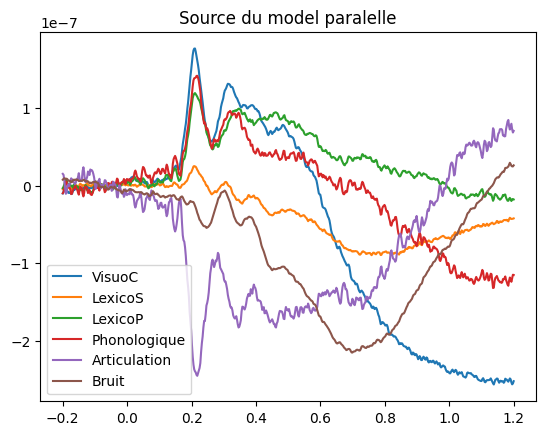

Seriel


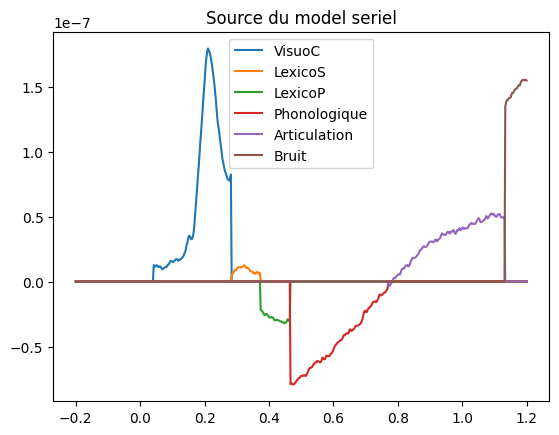

In [11]:
time = np.linspace(-0.2,1.2,simulation_obj.Alpha_matrix.shape[1])
labels = ["VisuoC",'LexicoS','LexicoP','Phonologique','Articulation','Bruit']

print("Paralelle1")
for region, l in zip(simulation_obj.Alpha_matrix,labels):
    plt.plot(time,region,label = l)
    plt.title("Source du model paralelle")
plt.legend()
plt.show()

print("Seriel")
for region, l in zip(simulation_seriel_obj.Alpha_matrix,labels):
    plt.plot(time,region,label = l)
    plt.title("Source du model seriel")
plt.legend()
plt.show()

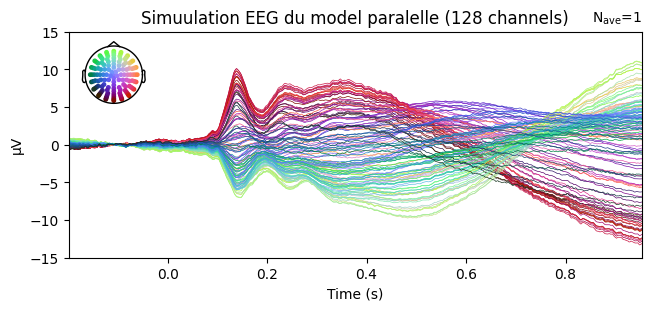

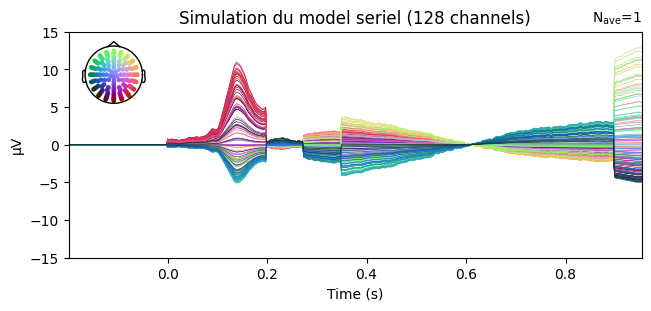

In [12]:
sim_para = simulation_obj.evoked_sim
sim_seri = simulation_seriel_obj.evoked_sim
sim_para.plot(titles = "Simuulation EEG du model paralelle", ylim=dict(eeg=[-15, 15]))
sim_seri.plot(titles = "Simulation du model seriel",ylim=dict(eeg=[-15, 15]))
print()

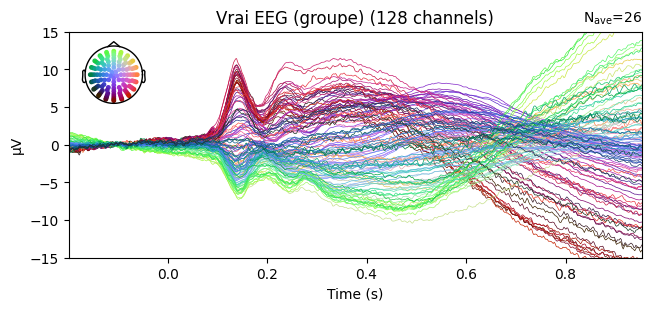

In [13]:
group_average.plot(titles = "Vrai EEG (groupe)",ylim=dict(eeg=[-15, 15]))
print()

In [14]:
def compute_RMSE(subject,group):
    return np.sqrt(np.mean((subject - group) ** 2))

In [15]:
# list_sim_obj 
# list_sim_serie_obj 

In [35]:
liste_RMSE_para = []
liste_name_para = []

liste_RMSE_seri = []
liste_name_seri = []

for sim_para, sim_seri in zip(list_sim_obj, list_sim_serie_obj) :
    group = sim_para.true_eeg_sub
    subject = sim_para.evoked_sim.data
    liste_RMSE_para.append(compute_RMSE(subject,group))
    liste_name_para.append(sim_para.name)

    group = sim_seri.true_eeg_sub
    subject = sim_seri.evoked_sim.data
    liste_RMSE_seri.append(compute_RMSE(subject,group))
    liste_name_seri.append(sim_para.name)

array_RMSE_para = np.array(liste_RMSE_para) * 10e6
array_name_para = np.array(liste_name_para) 

array_RMSE_seri = np.array(liste_RMSE_seri) * 10e6
array_name_seri = np.array(liste_name_seri)

print("===== stats RMSE du model paralelle =====")
print("mean = ",array_RMSE_para.mean())
print("std = ", array_RMSE_para.std())
print("max = ",array_RMSE_para.max())
print("min = ",array_RMSE_para.min())
print("=========================================")


print("===== stats RMSE du model seriel =====")
print("mean = ",array_RMSE_seri.mean())
print("std = ",array_RMSE_seri.std())
print("max = ",array_RMSE_seri.max())
print("min = ",array_RMSE_seri.min())
print("=========================================")


dico = {
    "RMSE_para" : array_RMSE_para,
    "Sub_para" : array_name_para,
    "RMSE_seri" : array_RMSE_seri,
    "Sub_seri" : array_name_seri,
}

df = pd.DataFrame(dico)

===== stats RMSE du model paralelle =====
mean =  56.67292043510666
std =  21.519564344348293
max =  114.65345435610199
min =  30.563218771534583
===== stats RMSE du model seriel =====
mean =  63.527003541426225
std =  23.809590488900806
max =  121.1565398855406
min =  29.764780211568603


In [36]:
meta_df = pd.read_csv("..\meta_data_subjects.csv")
meta_df["rmse_inra"]
df["err_RMSE"] = meta_df["rmse_inra"] * 100

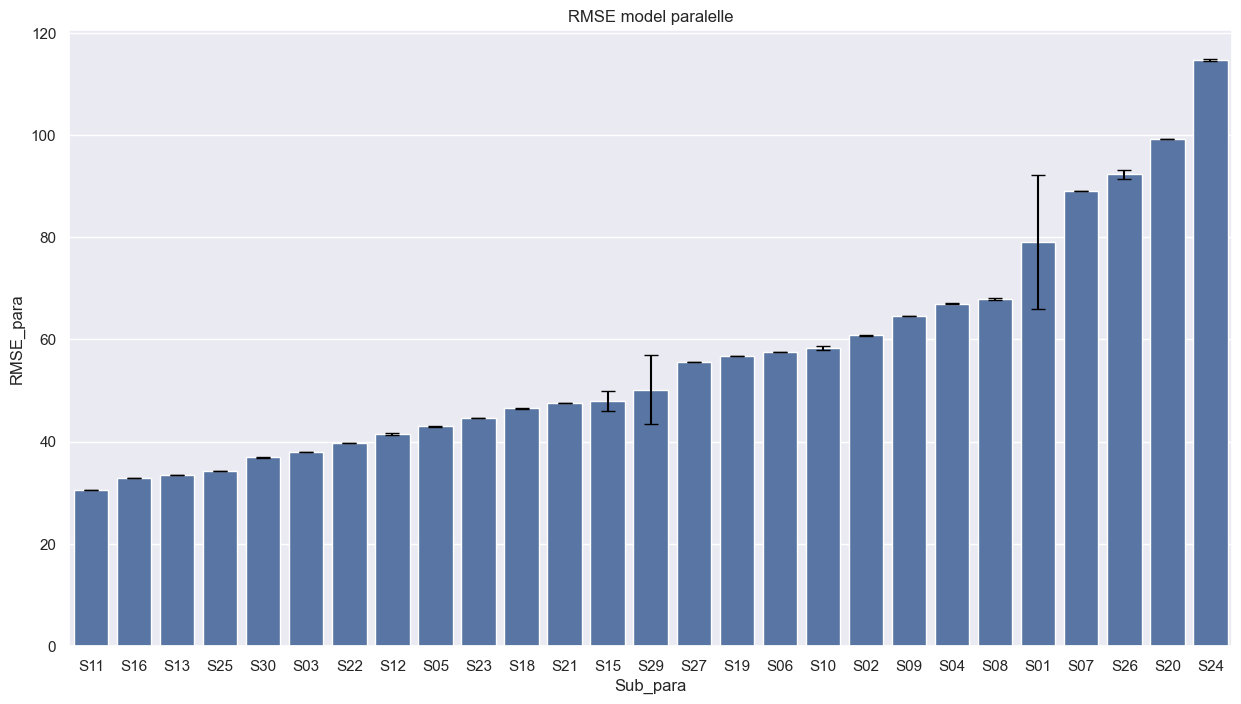

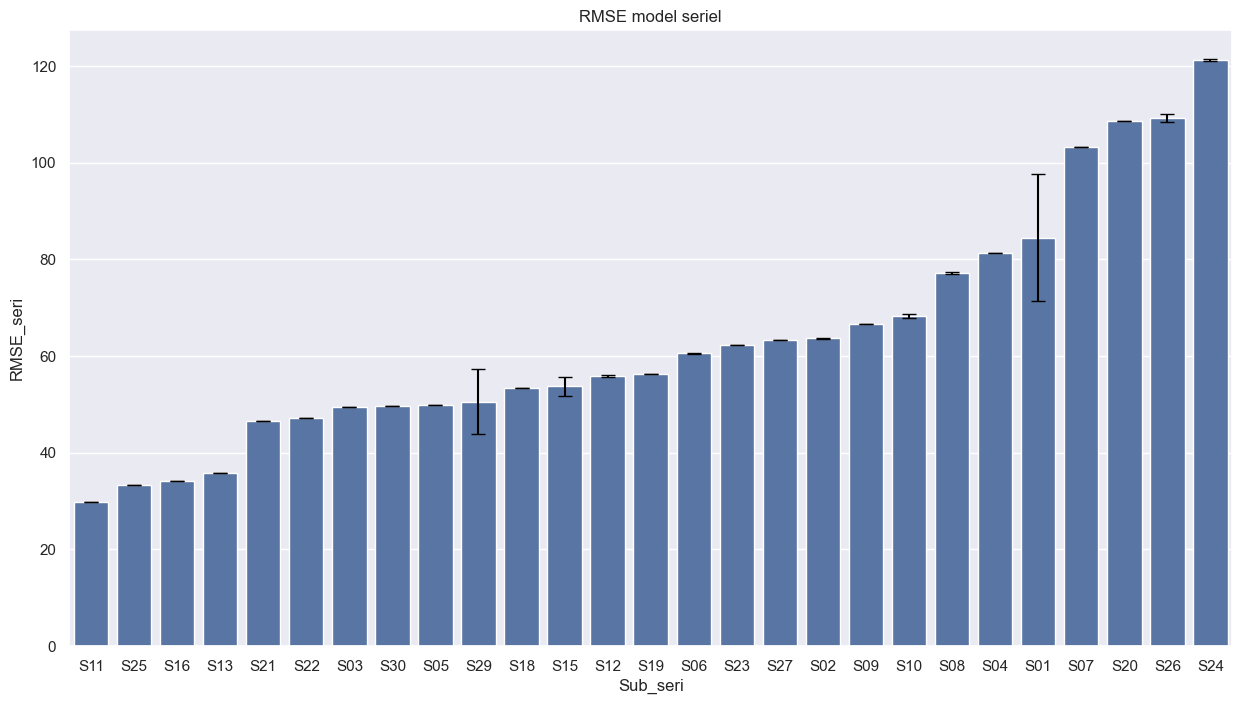

In [37]:
df = df.sort_values("RMSE_para")
# plt.ylim(15, 20)
sns.set(rc={"figure.figsize": (15, 8)})
plt.title("RMSE model paralelle")

plt.errorbar(
    df["Sub_para"],
    df["RMSE_para"],
    yerr=df["err_RMSE"],   
    fmt='none',
    ecolor='black',
    capsize=5
)

sns.barplot(data = df, y = "RMSE_para", x = "Sub_para")
plt.show()

df = df.sort_values("RMSE_seri")
sns.set(rc={"figure.figsize": (15, 8)})
# plt.ylim(25, 40)
plt.title("RMSE model seriel")

plt.errorbar(
    df["Sub_seri"],
    df["RMSE_seri"],
    yerr=df["err_RMSE"],   
    fmt='none',
    ecolor='black',
    capsize=5
)

sns.barplot(data = df, y = "RMSE_seri", x = "Sub_seri")
plt.show()

